# Regression


In [17]:
# decision tree, Naive bayes, randomforest, support vector machine, KNeighborsRegressor

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#load data 'mpg'
data = sns.load_dataset('mpg')
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [5]:
data.drop(['origin','name'], axis=1, inplace=True)

In [7]:
data['horsepower']=data['horsepower'].fillna(data['horsepower'].mean())

In [8]:
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
dtype: int64

# Train with KNeighborsRegressor 

In [9]:
# create train test data
from sklearn.model_selection import train_test_split

In [11]:
X = data.drop('mpg', axis=1)
y = data.mpg

In [12]:
X.head()


,cylinders,displacement,horsepower,weight,acceleration,model_year
0,8,307.0,130.0,3504,12.0,70
1,8,350.0,165.0,3693,11.5,70
2,8,318.0,150.0,3436,11.0,70
3,8,304.0,150.0,3433,12.0,70
4,8,302.0,140.0,3449,10.5,70


In [13]:
y.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

In [14]:
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [16]:
from sklearn.neighbors import KNeighborsRegressor

In [19]:
# Create Model
knn = KNeighborsRegressor()

In [20]:
# fit the modle
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [21]:
# predict the Model
y_pred = knn.predict(X_test)
y_pred [0:10]

array([33.74, 28.78, 24.64, 15.1 , 15.  , 33.7 , 22.32, 13.2 , 15.1 ,
       24.7 ])

In [22]:
# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [23]:
ms = mean_squared_error(y_test,y_pred)
ma = mean_absolute_error(y_test,y_pred)
rs = r2_score(y_test,y_pred)

In [24]:
print("mean square error:",ms)
print("mean absolute error:",ma)
print("R2 socre:",rs)


mean square error: 12.581365000000002
mean absolute error: 2.7692500000000004
R2 socre: 0.7659996807953288


# Train all the model and get metrics in a single loop

In [30]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression

In [44]:
mdl_name=['dt','rf','svr','lr']

In [39]:
mdls = {
    'dt':DecisionTreeRegressor(),
    'rf':RandomForestRegressor(),
    'svr':SVR(),
    'lr':LinearRegression(),
}

In [41]:
r_score = []

In [48]:
import joblib

In [49]:
for name, model in mdls.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rs = r2_score(y_test,y_pred)
    r_score.append(rs)
    # save the model
    joblib.dump(model, f"{name}.plk")

In [43]:
print(r_score)

[0.7851819983909574, 0.9074882091304393, 0.74524293439152, 0.8244069426990219]


In [46]:
mdl_name = list(mdls.keys())
mdl_name

['dt', 'rf', 'svr', 'lr']

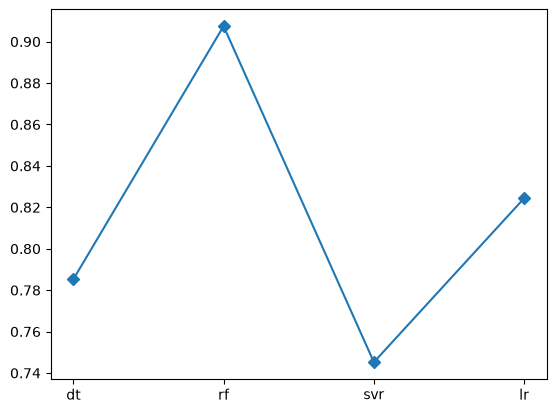

In [47]:
plt.plot(mdl_name,r_score, marker='D')

# demo of Using model for predictions

In [50]:
# load model
model = joblib.load('rf.plk')
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [54]:
# from 'data' we take 50 records as sample
sample = data.sample(n=50)
sample.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
142,26.0,4,79.0,67.0,1963,15.5,74
360,30.7,6,145.0,76.0,3160,19.6,81
231,15.5,8,400.0,190.0,4325,12.2,77
235,26.0,4,97.0,75.0,2265,18.2,77
281,19.8,6,200.0,85.0,2990,18.2,79


In [58]:
sample_predict = model.predict(sample.drop('mpg', axis=1))
sample_predict

array([27.82 , 28.169, 15.489, 26.821, 20.31 , 15.125, 31.495, 21.73 ,
       25.515, 28.213, 29.283, 19.234, 17.13 , 20.217, 10.23 , 34.482,
       37.721, 19.838, 13.31 , 26.811, 12.435, 20.916, 37.746, 20.424,
       26.122, 25.199, 30.241, 20.688, 21.707, 11.75 , 23.3  , 17.326,
       18.234, 23.429, 18.819, 33.622, 28.294, 22.603, 26.95 , 24.239,
       33.239, 27.278, 32.19 , 19.577, 15.511, 17.537, 13.6  , 18.243,
       28.55 , 18.82 ])

In [59]:
rs = r2_score(sample['mpg'],sample_predict)
rs

0.9511145706145707

In [61]:
# check accuracy of 10 Samples
for x in range(10):
    df = data.sample(n=50)
    df_pred=model.predict(df.drop('mpg',axis=1))
    rs = r2_score(df['mpg'], df_pred)
    print("r2 score: ", rs)

r2 score:  0.9768199927039186
r2 score:  0.9626455256995262
r2 score:  0.9196008724938977
r2 score:  0.9650175337733262
r2 score:  0.9851913948826957
r2 score:  0.9603230597840009
r2 score:  0.9650212743752179
r2 score:  0.9703702124459215
r2 score:  0.9566039924139037
r2 score:  0.9616237732126516
